# Calibrated BOAMP Survival Analysis

This notebook reruns core survival diagnostics using the calibrated broad, balanced, and strict proxy-event definitions. The balanced definition is treated as the main specification; broad and strict are sensitivity bounds.

Real BOAMP event labels remain proxy recurrences: identifiable reappearances of similar procurement needs under the selected matching rule, not certified recurrence chains.


In [1]:
from __future__ import annotations

import os
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter, LogNormalAFTFitter, WeibullAFTFitter, LogLogisticAFTFitter

_cwd = Path.cwd()
PROJ = _cwd
for candidate in [_cwd, *_cwd.parents]:
    if (candidate / "data").exists() and (candidate / "notebooks").exists():
        PROJ = candidate
        break
os.chdir(PROJ)

PROCESSED = PROJ / "data" / "processed"
REPORT_TABLES = PROJ / "reports" / "tables" / "survival"
VALIDATION_TABLES = PROJ / "reports" / "tables" / "validation"
REPORT_FIGURES = PROJ / "reports" / "figures" / "survival"

REPORT_TABLES.mkdir(parents=True, exist_ok=True)
REPORT_FIGURES.mkdir(parents=True, exist_ok=True)

ACADEMIC_PALETTE = ["#1b4d89", "#b85c38", "#2f6f4e", "#7a5195", "#5c677d", "#8a6f3f"]
sns.set_theme(context="paper", style="ticks", palette=ACADEMIC_PALETTE, font="serif")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Times"],
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "legend.frameon": False,
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "grid.color": "#d9d9d9",
    "grid.linewidth": 0.45,
    "grid.alpha": 0.7,
})


## 1. Load Calibrated Survival Datasets


In [2]:
rule_paths = {
    "broad": PROCESSED / "boamp_phase2_survival_calibrated_broad.csv",
    "balanced": PROCESSED / "boamp_phase2_survival_calibrated_balanced.csv",
    "strict": PROCESSED / "boamp_phase2_survival_calibrated_strict.csv",
}
missing = [name for name, path in rule_paths.items() if not path.exists()]
if missing:
    raise SystemExit("Missing calibrated survival datasets: " + ", ".join(missing))

dfs = {}
for name, path in rule_paths.items():
    d = pd.read_csv(path, parse_dates=["start_date"])
    d["rule_name"] = name
    d["start_year"] = d["start_date"].dt.year
    d["event"] = pd.to_numeric(d["event"], errors="coerce").fillna(0).astype(int)
    d["observed_duration_months"] = pd.to_numeric(d["observed_duration_months"], errors="coerce")
    d["declared_duration_months"] = pd.to_numeric(d["declared_duration_months"], errors="coerce")
    d["dur_was_imputed"] = d["dur_was_imputed"].astype(str).str.lower().isin(["true", "1", "yes"]).astype(int)
    dfs[name] = d

loaded = pd.DataFrame([
    {
        "rule_name": name,
        "path": str(path.relative_to(PROJ)),
        "rows": len(dfs[name]),
        "events": int(dfs[name]["event"].sum()),
        "event_rate": float(dfs[name]["event"].mean()),
    }
    for name, path in rule_paths.items()
])
display(loaded)


,rule_name,path,rows,events,event_rate
0,broad,data/processed/boamp_phase2_survival_calibrate...,1210,490,0.404959
1,balanced,data/processed/boamp_phase2_survival_calibrate...,1210,269,0.222314
2,strict,data/processed/boamp_phase2_survival_calibrate...,1210,79,0.065289


## 2. Kaplan-Meier Summary


In [3]:
km_rows = []
kmf = KaplanMeierFitter()
time_points = [12, 24, 36, 48, 60]
for name, d in dfs.items():
    kmf.fit(d["observed_duration_months"], event_observed=d["event"], label=name)
    row = {
        "rule_name": name,
        "n": len(d),
        "events": int(d["event"].sum()),
        "event_rate": float(d["event"].mean()),
        "km_median_months": float(kmf.median_survival_time_) if np.isfinite(kmf.median_survival_time_) else np.inf,
    }
    for t in time_points:
        row[f"survival_{t}m"] = float(kmf.survival_function_at_times(t).iloc[0])
    km_rows.append(row)

km_summary = pd.DataFrame(km_rows)
km_summary.to_csv(REPORT_TABLES / "calibrated_rule_km_summary.csv", index=False)
display(km_summary)


,rule_name,n,events,event_rate,km_median_months,survival_12m,survival_24m,survival_36m,survival_48m,survival_60m
0,broad,1210,490,0.404959,inf,0.913722,0.842905,0.802864,0.682962,0.556842
1,balanced,1210,269,0.222314,inf,0.959326,0.922993,0.905460,0.832499,0.751797
2,strict,1210,79,0.065289,inf,0.990037,0.981593,0.976275,0.957503,0.924718


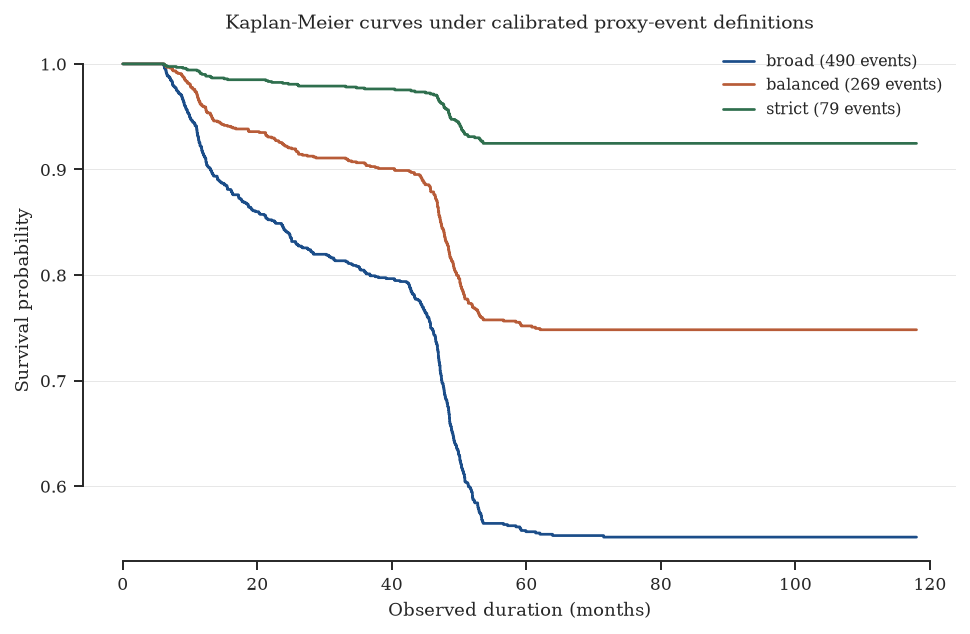

/home/senghakrou/stage-1/reports/figures/survival/calibrated_rules_km_curves.png


In [4]:
def style_axes(ax, grid_axis="y"):
    ax.grid(True, axis=grid_axis, color="#d9d9d9", linewidth=0.45, alpha=0.7)
    ax.grid(False, axis="x" if grid_axis == "y" else "y")
    sns.despine(ax=ax, trim=True)
    return ax

def savefig(name):
    fig = plt.gcf()
    for ax in fig.axes:
        style_axes(ax)
    path = REPORT_FIGURES / name
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print(path)

fig, ax = plt.subplots(figsize=(7.0, 4.6))
for name in ["broad", "balanced", "strict"]:
    d = dfs[name]
    kmf.fit(d["observed_duration_months"], event_observed=d["event"], label=f"{name} ({int(d['event'].sum())} events)")
    kmf.plot_survival_function(ax=ax, ci_show=False, linewidth=1.4)
ax.set_title("Kaplan-Meier curves under calibrated proxy-event definitions")
ax.set_xlabel("Observed duration (months)")
ax.set_ylabel("Survival probability")
savefig("calibrated_rules_km_curves.png")


## 3. Cox Models Across Event Definitions


In [5]:
def fit_cox_for_rule(name: str, d: pd.DataFrame):
    model_df = d[["observed_duration_months", "event", "declared_duration_months", "start_year", "dur_was_imputed", "category_label"]].copy()
    top_cats = model_df["category_label"].value_counts().head(5).index
    model_df["category_model"] = np.where(model_df["category_label"].isin(top_cats), model_df["category_label"], "Other")
    model_df = pd.get_dummies(model_df.drop(columns=["category_label"]), columns=["category_model"], drop_first=True)
    model_df = model_df.dropna()
    cph = CoxPHFitter(penalizer=0.1)
    cph.fit(model_df, duration_col="observed_duration_months", event_col="event")
    s = cph.summary.reset_index().rename(columns={"index": "variable"})
    if "variable" not in s.columns and "covariate" in s.columns:
        s = s.rename(columns={"covariate": "variable"})
    s["rule_name"] = name
    s["c_index"] = cph.concordance_index_
    s["n_events"] = int(model_df["event"].sum())
    s["n_rows"] = len(model_df)
    return s, cph

cox_tables = []
cox_models = {}
for name, d in dfs.items():
    try:
        table, model = fit_cox_for_rule(name, d)
        cox_tables.append(table)
        cox_models[name] = model
    except Exception as exc:
        cox_tables.append(pd.DataFrame([{"rule_name": name, "variable": "MODEL_FAILED", "error": str(exc)}]))

cox_comparison = pd.concat(cox_tables, ignore_index=True)
cox_comparison.to_csv(REPORT_TABLES / "calibrated_rule_cox_comparison.csv", index=False)
display_cols = [c for c in ["rule_name", "variable", "coef", "exp(coef)", "p", "c_index", "n_events"] if c in cox_comparison.columns]
display(cox_comparison[display_cols].head(40))


,rule_name,variable,coef,exp(coef),p,c_index,n_events
0,broad,declared_duration_months,-0.007158,0.992868,0.005331,0.626344,490
1,broad,start_year,0.050836,1.052150,0.019135,0.626344,490
2,broad,dur_was_imputed,-0.138508,0.870656,0.178003,0.626344,490
3,broad,category_model_IT Services & Consulting,0.299353,1.348985,0.004909,0.626344,490
4,broad,category_model_Other,-0.019053,0.981127,0.887739,0.626344,490
5,broad,category_model_Software & Applications,0.148828,1.160473,0.213864,0.626344,490
6,broad,category_model_Telecom & Networks,-0.172330,0.841701,0.170144,0.626344,490
7,broad,category_model_Unknown,-0.388510,0.678066,0.019541,0.626344,490
8,balanced,declared_duration_months,0.001259,1.001260,0.687122,0.592042,269
9,balanced,start_year,0.043628,1.044594,0.101237,0.592042,269


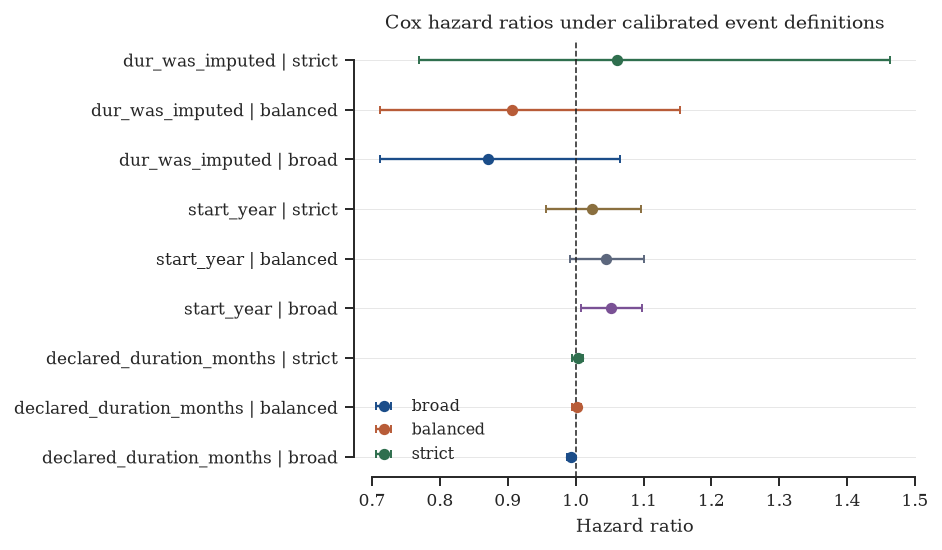

/home/senghakrou/stage-1/reports/figures/survival/calibrated_rules_cox_hazard_ratios.png


In [6]:
plot_vars = ["declared_duration_months", "start_year", "dur_was_imputed"]
coef_plot = cox_comparison[cox_comparison["variable"].isin(plot_vars)].copy()
if not coef_plot.empty:
    coef_plot["hr"] = coef_plot["exp(coef)"]
    coef_plot["hr_low"] = coef_plot["exp(coef) lower 95%"]
    coef_plot["hr_high"] = coef_plot["exp(coef) upper 95%"]
    fig, ax = plt.subplots(figsize=(6.8, 4.0))
    y_labels = []
    y_positions = []
    pos = 0
    for var in plot_vars:
        for rule in ["broad", "balanced", "strict"]:
            r = coef_plot[(coef_plot["variable"].eq(var)) & (coef_plot["rule_name"].eq(rule))]
            if len(r):
                rr = r.iloc[0]
                ax.errorbar(rr["hr"], pos, xerr=[[rr["hr"] - rr["hr_low"]], [rr["hr_high"] - rr["hr"]]], fmt="o", capsize=2, label=rule if pos < 3 else None)
                y_labels.append(f"{var} | {rule}")
                y_positions.append(pos)
                pos += 1
    ax.axvline(1.0, color="#222222", linestyle="--", linewidth=0.8)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(y_labels)
    ax.set_xlabel("Hazard ratio")
    ax.set_title("Cox hazard ratios under calibrated event definitions")
    ax.legend()
    savefig("calibrated_rules_cox_hazard_ratios.png")


## 4. Parametric AFT Check for Balanced Rule


In [7]:
balanced = dfs["balanced"].copy()
aft_df = balanced[["observed_duration_months", "event", "declared_duration_months", "start_year", "dur_was_imputed"]].dropna()
aft_rows = []
for model_name, cls in [
    ("WeibullAFT", WeibullAFTFitter),
    ("LogNormalAFT", LogNormalAFTFitter),
    ("LogLogisticAFT", LogLogisticAFTFitter),
]:
    try:
        m = cls(penalizer=0.01)
        m.fit(aft_df, duration_col="observed_duration_months", event_col="event")
        aft_rows.append({
            "model": model_name,
            "AIC": float(m.AIC_),
            "log_likelihood": float(m.log_likelihood_),
            "n_rows": len(aft_df),
            "n_events": int(aft_df["event"].sum()),
        })
    except Exception as exc:
        aft_rows.append({"model": model_name, "AIC": np.nan, "log_likelihood": np.nan, "error": str(exc)})

aft_comparison = pd.DataFrame(aft_rows).sort_values("AIC")
aft_comparison.to_csv(REPORT_TABLES / "calibrated_balanced_aft_comparison.csv", index=False)
display(aft_comparison)


,model,AIC,log_likelihood,n_rows,n_events
1,LogNormalAFT,3544.795217,-1767.397609,1210,269
0,WeibullAFT,3571.809125,-1780.904563,1210,269
2,LogLogisticAFT,3580.517754,-1785.258877,1210,269


## 5. Verification and Conclusion


In [8]:
expected = [
    REPORT_TABLES / "calibrated_rule_km_summary.csv",
    REPORT_TABLES / "calibrated_rule_cox_comparison.csv",
    REPORT_TABLES / "calibrated_balanced_aft_comparison.csv",
    REPORT_FIGURES / "calibrated_rules_km_curves.png",
    REPORT_FIGURES / "calibrated_rules_cox_hazard_ratios.png",
]
verification = pd.DataFrame([
    {"file": str(p.relative_to(PROJ)), "exists": p.exists(), "size_bytes": p.stat().st_size if p.exists() else 0}
    for p in expected
])
verification["status"] = np.where(verification["exists"] & (verification["size_bytes"] > 0), "PASS", "FAIL")
verification.to_csv(REPORT_TABLES / "calibrated_survival_analysis_verification.csv", index=False)
display(verification)
if (verification["status"] != "PASS").any():
    raise SystemExit("Verification failed.")

balanced_summary = km_summary[km_summary["rule_name"].eq("balanced")].iloc[0]
print("FINAL STATUS: PASS")
print(f"Balanced events: {int(balanced_summary['events'])} / {int(balanced_summary['n'])} ({balanced_summary['event_rate']:.1%})")
print(f"Balanced KM median: {balanced_summary['km_median_months']}")
print("Use broad and strict as sensitivity bounds in the report.")


,file,exists,size_bytes,status
0,reports/tables/survival/calibrated_rule_km_sum...,True,514,PASS
1,reports/tables/survival/calibrated_rule_cox_co...,True,6420,PASS
2,reports/tables/survival/calibrated_balanced_af...,True,219,PASS
3,reports/figures/survival/calibrated_rules_km_c...,True,130009,PASS
4,reports/figures/survival/calibrated_rules_cox_...,True,123637,PASS


FINAL STATUS: PASS
Balanced events: 269 / 1210 (22.2%)
Balanced KM median: inf
Use broad and strict as sensitivity bounds in the report.


## Final Interpretation

The balanced calibrated proxy-event definition produces enough events for the main survival analysis and avoids the very high runner-up pass rate of the broad rule. The strict rule remains useful as a robustness lower bound but has far fewer events.

The survival conclusions should be reported as conditional on the proxy-event construction. Real BOAMP does not supply certified recurrence-chain labels.
